# Experiment No 4: Effect of Residual Connections

### Reason for Experimentation
In the experiment done in `03_batch_normalization_analysis.ipynb` we saw how batch normalization helped solve for stabilizing the data distribution across the layers of models allowing for faster convergence compared to plain models. We also saw that even with an introduction of batch normalization layers deeper models like the 56 layer bn normalization model performed poorly compared to the 20 layer model. 

In this experiment we want to see if residual connections help resolve this issue of not being able to build deeper models to improve model performance. To know more about **Residual Connections** you can have a look at [Residual Net](https://github.com/Vaibhavsareen1/computer-vision/blob/main/notebooks/resnet.ipynb)

### Experiment Design
This experiment follows the same design as that of `03_batch_normalization_analysis.ipynb` only models have changed to ResNet20 and ResNet56 model. These ResNet models incorporate **Identity Reduction** for simiplicity.

### Expected Result
The expectation is that residual connections allow models to dynamically decide how much information is to be learned from a given state of input features allowing for better performance when we build deeper models.


### Import libraries to be used througout the experiment

In [1]:
import json
import torch
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from pathlib import Path
from torch.optim import SGD
from torch.optim.lr_scheduler import MultiStepLR

from torchvision.transforms import v2
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# RANDOM STATE FOR REPRODUCIBILITY
RANDOM_STATE = 42
# SETUP DEVICE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

%matplotlib inline

### Result and dataset storage paths

In [2]:
current_dir = Path.cwd()

# Path to the folder where CIFAR 10 dataset will be downloaded
dataset_root_folder = current_dir.parent / 'datasets' / 'cifar10_dataset'

# Path to the file where the results of this experimentation will be stored
results_path = current_dir.parent / 'results' / '04_effect_of_residual_connections.json'

# Path to the file where the results of batch normalization experimentation is stored
bn_results_path = current_dir.parent / 'results' / '03_batch_normalization_analysis.json'

# Store the absolute path required for the dataset and result file
dataset_root_abs_path = dataset_root_folder.absolute()
result_abs_path = results_path.absolute()
bn_results_abs_path = bn_results_path.absolute()

### Classes to be used throughout the experiment

In [3]:
class ConvBlockV1(torch.nn.Module):
    """
    Class that implements residual connections across two convolution layer described in the paper
    "Deep Residual Learning for Image Recognition".

    This block does not perform reduction of feature maps 
    """
    def __init__(self, in_channels: int) -> None:
        """
        Method to instantiate  object of :class: ConvBlockV1

        :param in_channels: Number of incoming channels of the input tensor
        
        :returns: An object of :class: ConvBlockV1
        """

        super().__init__()

        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=in_channels),
                                torch.nn.ReLU())

        self.conv_layer_2 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=in_channels, out_channels=in_channels, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=in_channels))
    
        self.relu_layer = torch.nn.ReLU()

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through the ConvBlock.

        :param X: Input tensor

        :retuns: Result of forward propagation through ConvBlock
        """

        output = self.conv_layer_1(X)
        output = self.conv_layer_2(output)

        return self.relu_layer(output + X)


class IdentityReductionV1(torch.nn.Module):
    """
    Class that implements residual connections across two convolution layers with feature map reduction
    and two folds increase of the number of dimension using "identity mapping" technique which uses 
    zero padded feature maps to increase the dimensions as described in the paper 
    "Deep Residual Learning for Image Recognition" 
    """

    def __init__(self, in_channels: int) -> None:
        """
        Method to instantiate  object of :class: IdentityReductionV1

        :param in_channels: Number of incoming channels of the input tensor
        
        :returns: An object of :class: IdentityReductionV1
        """

        super().__init__()

        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=in_channels, out_channels=in_channels * 2, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features= in_channels * 2),
                                torch.nn.ReLU())

        self.conv_layer_2 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=in_channels * 2, out_channels=in_channels * 2, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=in_channels * 2))

        self.relu_layer = torch.nn.ReLU()

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through the IdentityReductionV1.

        :param X: Input tensor

        :retuns: Result of forward propagation through IdentityReductionV1
        """
    
        output = self.conv_layer_1(X)
        output = self.conv_layer_2(output)

        down_sampled_input = X[:, :, ::2, ::2]
        zero_tensor = torch.zeros_like(down_sampled_input)
        identity_output = torch.concat((down_sampled_input, zero_tensor), dim=1)

        return self.relu_layer(output + identity_output)
        return self.relu_layer(output + projection_output)


class ResNetBlockIdentityV1(torch.nn.Module):
    """
    Class that represents empherical representation of residual layers with identity mapping technique
    described in the paper "Deep Residual Learning for Image Recognition".

    This block is for ResNet 18 and 34 layer architecture
    """
    def __init__(self, in_channels: int, num_blocks: int, reduce: bool = True):
        """
        Method to instantiate  object of :class: ResNetBlockIdentityV1

        :param in_channels: Number of incoming channels of the input tensor
        :param num_blocks: Total number of ConvBlock and Reduction blocks present in this residual connection layer block
        :param reduce: If reduction of feature maps and increase in dimenions needs to take place. Defaults to True
     
        :returns: An object of :class: ResNetBlockIdentityV1
        """

        super().__init__()

        self.conv_layers = torch.nn.ModuleList()
        if reduce:
            self.conv_layers.append(IdentityReductionV1(in_channels=in_channels))
            in_channels = in_channels * 2
        else:
            self.conv_layers.append(ConvBlockV1(in_channels=in_channels))

        for _ in range(num_blocks - 1):
            self.conv_layers.append(ConvBlockV1(in_channels=in_channels))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through the ResNetBlockIdentityV1.

        :param X: Input tensor

        :retuns: Result of forward propagation through ResNetBlockIdentityV1
        """

        for layer in self.conv_layers:
            X = layer(X)
        
        return X


class ResNet20(torch.nn.Module):
    """
    Class representing a CNN model to be trained on CIFAR 10 dataset inspired by ResNet architecture.

    This is an 20 layer model with residual connections and batch normalization layers 
    """

    def __init__(self, num_classes: int = 10) -> None:
        """
        Method to initialize an instance of :class: ResNet20

        :param num_classes: Number of classes present in the dataset. Defaults to 10 for CIFAR 10

        :returns: Instance of :class: ResNet20
        """

        super().__init__()

        # Input: (N, 3, 32, 32) -> Output: (N, 16, 32, 32) (Layer 1)
        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU())

        # Input: (N, 16, 32, 32) -> Output: (N, 16, 32, 32) (Layer 2 and 7)
        self.conv_layer_2 = ResNetBlockIdentityV1(in_channels=16, num_blocks=6, reduce=False)
        # Input: (N, 16, 32, 32) -> Output: (N, 32, 16, 16) (Layer 8 to 13)
        self.conv_layer_3 = ResNetBlockIdentityV1(in_channels=16, num_blocks=6, reduce=True)
        # Input: (N, 32, 16, 16) -> Output: (N, 64, 8, 8) (Layer 14 to 19)
        self.conv_layer_4 = ResNetBlockIdentityV1(in_channels=32, num_blocks=6, reduce=True)
        # Input: (N, 64, 8, 8) -> Output: (N, 64, 1, 1)
        self.average_pooling_layer = torch.nn.AvgPool2d(kernel_size=8, stride=1, padding=0)

        # 20th layer
        self.classifer = torch.nn.Sequential(torch.nn.Flatten(),
                                             torch.nn.Linear(in_features=64, out_features=num_classes))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through ResNet20 model

        :param X: Input tensor

        :returns: Result of forward propagation
        """

        X = self.conv_layer_1(X)
        X = self.conv_layer_2(X)
        X = self.conv_layer_3(X)
        X = self.conv_layer_4(X)
        X = self.average_pooling_layer(X)

        return self.classifer(X)


class ResNet56(torch.nn.Module):
    """
    Class representing a CNN model to be trained on CIFAR 10 dataset inspired by ResNet architecture.

    This is an 56 layer model with residual connections and batch normalization layers 
    """

    def __init__(self, num_classes: int = 10) -> None:
        """
        Method to initialize an instance of :class: ResNet56

        :param num_classes: Number of classes present in the dataset. Defaults to 10 for CIFAR 10

        :returns: Instance of :class: ResNet56
        """

        super().__init__()
        # Input: (N, 3, 32, 32) -> Output: (N, 16, 32, 32) (Layer 1)
        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU())
        # Input: (N, 16, 32, 32) -> Output: (N, 16, 32, 32) (Layer 2 and 19)
        self.conv_layer_2 = ResNetBlockIdentityV1(in_channels=16, num_blocks=18, reduce=False)
        # Input: (N, 16, 32, 32) -> Output: (N, 32, 16, 16) (Layer 20 to 37)
        self.conv_layer_3 = ResNetBlockIdentityV1(in_channels=16, num_blocks=18, reduce=True)
        # Input: (N, 32, 16, 16) -> Output: (N, 64, 8, 8) (Layer 38 to 55)
        self.conv_layer_4 = ResNetBlockIdentityV1(in_channels=32, num_blocks=18, reduce=True)
        # Input: (N, 64, 8, 8) -> Output: (N, 64, 1, 1)
        self.average_pooling_layer = torch.nn.AvgPool2d(kernel_size=8, stride=1, padding=0)

        # 56th layer
        self.classifer = torch.nn.Sequential(torch.nn.Flatten(),
                                             torch.nn.Linear(in_features=64, out_features=num_classes))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through ResNet56 model

        :param X: Input tensor

        :returns: Result of forward propagation
        """

        X = self.conv_layer_1(X)
        X = self.conv_layer_2(X)
        X = self.conv_layer_3(X)
        X = self.conv_layer_4(X)
        X = self.average_pooling_layer(X)

        return self.classifer(X)
    
def initialize_weights_kaiming(module):
    if isinstance(module, torch.nn.Conv2d):
        # Kaiming He initialization specifically designed for ReLU activation
        torch.nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        if module.bias is not None:
            torch.nn.init.constant_(module.bias, 0)
    elif isinstance(module, torch.nn.Linear):
        # Standard initialization for the final fully connected layer
        torch.nn.init.normal_(module.weight, 0, 0.01)
        torch.nn.init.constant_(module.bias, 0)

### Experiment configuration

In [4]:
GAMMA = 0.1
NUM_CLASSES = 10
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.0001
TOTAL_ITERATIONS = 32000
ITERATION_COMPLETION_RATE_50 = int(round(TOTAL_ITERATIONS * 0.5, 0))
ITERATION_COMPLETION_RATE_75 = int(round(TOTAL_ITERATIONS * 0.75, 0))

TRAIN_BATCH_SIZE = 256
TEST_BATCH_SIZE = 1024

TRAINING_SAMPLES = 50000

ITERATIONS_PER_BATCH = int(round(TRAINING_SAMPLES / TRAIN_BATCH_SIZE, 0))
TOTAL_EPOCHS = int(round(TOTAL_ITERATIONS / ITERATIONS_PER_BATCH, 0))

EPOCH_COMPLETION_RATE_50 = int(round(ITERATION_COMPLETION_RATE_50 / ITERATIONS_PER_BATCH, 0))
EPOCH_COMPLETION_RATE_75 = int(round(ITERATION_COMPLETION_RATE_75 / ITERATIONS_PER_BATCH, 0))

loss_function = torch.nn.CrossEntropyLoss()
result_dict = {}

### Load Datasets

In [5]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

# Transforms required to convert images into 3x32x32 normalized tensors
feature_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32),
    v2.Normalize(mean=(0.491, 0.482, 0.446), std=(0.247, 0.243, 0.261))
])

# Convert class labels to one hot encoded labels
target_transforms = v2.Lambda(lambda x: torch.nn.functional.one_hot(torch.tensor(x), num_classes=NUM_CLASSES).float())


# Load CIFAR 10 dataset train and test (set `download` to True if you want to download it for the first time)
train_dataset = CIFAR10(root=dataset_root_abs_path,
                        train=True,
                        download=False,
                        transform=feature_transforms,
                        target_transform=target_transforms)

test_dataset = CIFAR10(root=dataset_root_abs_path,
                       train=False,
                       download=False,
                       transform=feature_transforms,
                       target_transform=target_transforms)

# Load the train and test datasets onto their train and test dataloaders
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=TRAIN_BATCH_SIZE,
                              shuffle=True,
                              pin_memory=True)

# Using the below data loader for faster error calculation
train_dataloader_v2 = DataLoader(dataset=train_dataset,
                              batch_size=TEST_BATCH_SIZE,
                              shuffle=True,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=TEST_BATCH_SIZE,
                              shuffle=False,
                              pin_memory=True)

/home/vaibhav/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Train and Evaluate ResNet 20 and ResNet 56 models on CIFAR 10

In [ ]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

resnet_20_model = ResNet20(num_classes=NUM_CLASSES)
resnet_56_model = ResNet56(num_classes=NUM_CLASSES)

resnet_20_model = resnet_20_model.to(DEVICE)
resnet_56_model = resnet_56_model.to(DEVICE)

resnet_20_model.apply(initialize_weights_kaiming)
resnet_56_model.apply(initialize_weights_kaiming)

resnet_20_optimizer = SGD(resnet_20_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
resnet_56_optimizer = SGD(resnet_56_model.parameters(), lr=LEARNING_RATE, momentum=0.9)

resnet_20_scheduler = MultiStepLR(optimizer=resnet_20_optimizer, milestones=[EPOCH_COMPLETION_RATE_50, EPOCH_COMPLETION_RATE_75], gamma=0.1)
resnet_56_scheduler = MultiStepLR(optimizer=resnet_56_optimizer, milestones=[EPOCH_COMPLETION_RATE_50, EPOCH_COMPLETION_RATE_75], gamma=0.1)

resnet_20_train_error_percentage_list = []
resnet_56_train_error_percentage_list = []

resnet_20_test_error_percentage_list = []
resnet_56_test_error_percentage_list = []

with tqdm(total=TOTAL_EPOCHS, desc="Experiment Life") as progress_bar:
    for epoch in range(TOTAL_EPOCHS):
        resnet_20_model.train()
        resnet_56_model.train()

        for X, y in train_dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            resnet_20_y_pred = resnet_20_model(X)
            resnet_56_y_pred = resnet_56_model(X)
    
            resnet_20_loss = loss_function(resnet_20_y_pred, y)
            resnet_56_loss = loss_function(resnet_56_y_pred, y)

            resnet_20_optimizer.zero_grad()
            resnet_56_optimizer.zero_grad()

            resnet_20_loss.backward()
            resnet_56_loss.backward()

            resnet_20_optimizer.step()
            resnet_56_optimizer.step()

        resnet_20_model.eval()
        resnet_56_model.eval()

        resnet_20_train_error = 0
        resnet_56_train_error = 0
        total_train_samples = 0

        resnet_20_test_error = 0
        resnet_56_test_error = 0
        total_test_samples = 0

        with torch.inference_mode():
            for X, y in train_dataloader_v2:
                X = X.to(DEVICE)
                y = y.to(DEVICE)

                resnet_20_y_pred = resnet_20_model(X)
                resnet_56_y_pred = resnet_56_model(X)

                y_argmax = y.argmax(dim=1, keepdim=True)
                resnet_20_y_pred_argmax = resnet_20_y_pred.argmax(dim=1, keepdim=True)
                resnet_56_y_pred_argmax = resnet_56_y_pred.argmax(dim=1, keepdim=True)

                resnet_20_batch_result = y_argmax != resnet_20_y_pred_argmax
                resnet_56_batch_result = y_argmax != resnet_56_y_pred_argmax

                resnet_20_train_error += resnet_20_batch_result.sum().item()
                resnet_56_train_error += resnet_56_batch_result.sum().item()

                total_train_samples += TEST_BATCH_SIZE
    
            for X, y in test_dataloader:
                X = X.to(DEVICE)
                y = y.to(DEVICE)

                resnet_20_y_pred = resnet_20_model(X)
                resnet_56_y_pred = resnet_56_model(X)

                y_argmax = y.argmax(dim=1, keepdim=True)
                resnet_20_y_pred_argmax = resnet_20_y_pred.argmax(dim=1, keepdim=True)
                resnet_56_y_pred_argmax = resnet_56_y_pred.argmax(dim=1, keepdim=True)

                resnet_20_batch_result = y_argmax != resnet_20_y_pred_argmax
                resnet_56_batch_result = y_argmax != resnet_56_y_pred_argmax

                resnet_20_test_error += resnet_20_batch_result.sum().item()
                resnet_56_test_error += resnet_56_batch_result.sum().item()

                total_test_samples += TEST_BATCH_SIZE

        resnet_20_train_error_percentage_list.append(round((resnet_20_train_error / total_train_samples) * 100, 3))
        resnet_56_train_error_percentage_list.append(round((resnet_56_train_error / total_train_samples) * 100, 3))

        resnet_20_test_error_percentage_list.append(round((resnet_20_test_error / total_test_samples) * 100, 3))
        resnet_56_test_error_percentage_list.append(round((resnet_56_test_error / total_test_samples) * 100, 3))

        resnet_20_scheduler.step()
        resnet_56_scheduler.step()

        progress_bar.update(1)

### Store result

In [ ]:
final_result_dict = {
                        'ResNet_20_Train': resnet_20_train_error_percentage_list,
                        'ResNet_20_Test': resnet_20_test_error_percentage_list,
                        'ResNet_56_Train': resnet_56_train_error_percentage_list,
                        'ResNet_56_Test': resnet_56_test_error_percentage_list
                    }

with Path.open(result_abs_path, mode='w') as file:
    json.dump(final_result_dict, file)

### Plot Graphs

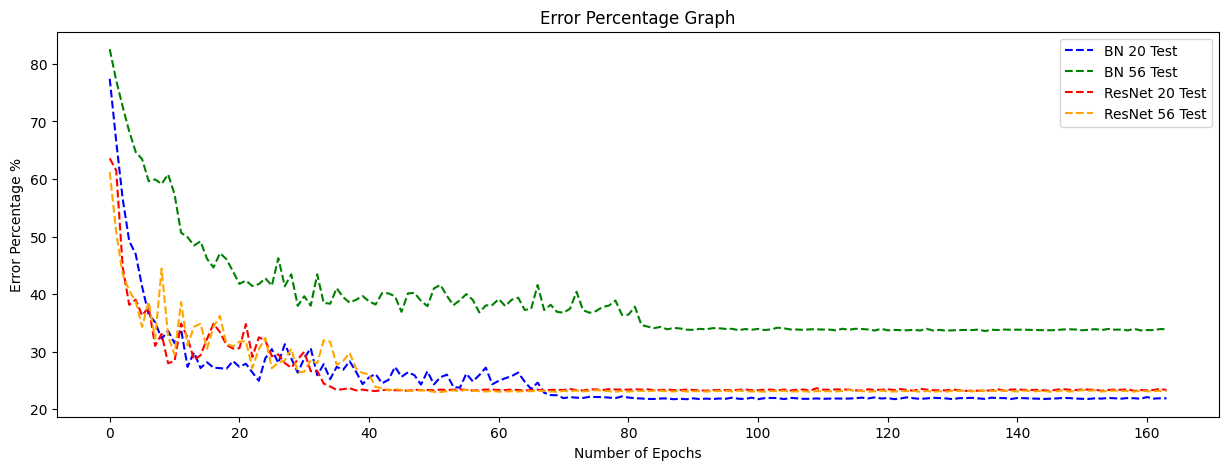

In [7]:
# Open batch normalization stored results
with Path.open(bn_results_abs_path, mode='r') as file:
    bn_experiment_results = json.load(file)

bn_df = pd.DataFrame(bn_experiment_results)

# Open residual net experimentation stored result
with Path.open(result_abs_path, mode='r') as file:
    experiment_results = json.load(file)

res_df = pd.DataFrame(experiment_results)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15,5))

axes.plot(list(range(TOTAL_EPOCHS)), bn_df["BN_20_Test"], color='blue', label='BN 20 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), bn_df["BN_56_Test"], color='green', label='BN 56 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), res_df["ResNet_20_Test"], color='red', label='ResNet 20 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), res_df["ResNet_56_Test"], color='orange', label='ResNet 56 Test', ls='--')
axes.set_title("Error Percentage Graph")
axes.set_xlabel("Number of Epochs")
axes.set_ylabel("Error Percentage %")
plt.legend()

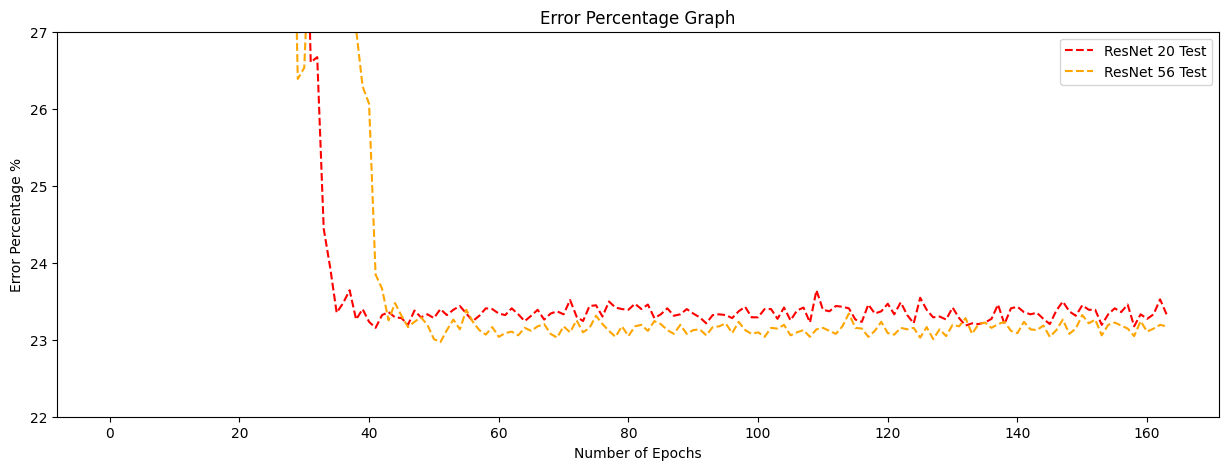

In [9]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15,5))

axes.plot(list(range(TOTAL_EPOCHS)), res_df["ResNet_20_Test"], color='red', label='ResNet 20 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), res_df["ResNet_56_Test"], color='orange', label='ResNet 56 Test', ls='--')
axes.set_title("Error Percentage Graph")
axes.set_xlabel("Number of Epochs")
axes.set_ylabel("Error Percentage %")
axes.set_ylim(22, 27)
plt.legend()

### Conclusion
The goal was to see if residual connections helped improve performance of deeper machine learning models. From the experiment's result we can observe the following:
1. By adding residual connections the performance of the 56 layer model with residual connections has improved significantly compared to the 56 layer model which only had batch normalization (as seen in graph 1).
2. The 56 layer ResNet model out performs the one 20 layer ResNet as we can see in the second graph.
3. This meets our expectation that addition of residual connections allows researchers to research on architecture which can go deeper and deeper.

Do note that The models did not perform better than 20 layer model with only batch normalization. This could be due to the following reasons
1. CIFAR 10 dataset which contains images of size 32x32 was too small of a dataset and larger models would not be able to perform better as they would over fit the training data. 
